<div style="font-family:'Georgia','Times New Roman',Times,serif; width:80%; margin:20px auto; padding:10px 20px 20px 20px; background:#ffffff; border-left:20px solid #003366; box-shadow:0 5px 20px rgba(0,0,0,0.1); text-align:center; border-radius:8px;">

  <div style="display:flex; align-items:center; justify-content:center; gap:20px; margin-bottom:15px; padding-bottom:1px; border-bottom:2px solid #eeeeee;">
    <img src="assets/Logotipo_de_la_Universidad_Nacional_de_Colombia.svg.png" alt="Logo Universidad" style="max-width:80px; height:auto;">
    <div style="font-size:1.1em; color:#003366; font-weight:bold; text-align:left;">Universidad Nacional de Colombia</div>
  </div>

  <h1 style="color:#003366; font-size:2.2em; margin:0.6em 0; font-weight:bold; line-height:1.2;">Detección de enfermedades en plantas de maíz y fríjol común con Inteligencia Artificial e imágenes multiespectrales</h1>
  <h2 style="color:#444444; font-size:1.4em; margin-bottom:0.8em; font-weight:normal; font-style:italic;">Análisis exploratorio de datos y entrenamiento de modelos de aprendizaje de máquina con datos de maíz — Dataset v2</h2>

  <div style="margin-bottom:0em; font-size:1.1em; color:#222222;">
    <p style="text-align:center; margin:0;"><strong>Autor:</strong> Selene Solano Vera</p>
  </div>

  <div style="margin:1.0em 0 1.0em 0; padding:0.8em 0; color:#666666; font-size:1em;">Medellín, Abril de 2026</div>

  <div style="height:0.1rem;"></div>

</div>

# Utilidades y Configuración Inicial

Esta sección incluye la importación de bibliotecas necesarias y la configuración del entorno de trabajo para el análisis exploratorio de datos y el entrenamiento de modelos de aprendizaje automático. Se utiliza el dataset v2 generado en `build_dataset_v2.ipynb`, el cual tiene formato largo (una fila por píxel por banda).

## Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
import joblib
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, ConfusionMatrixDisplay, accuracy_score, f1_score
import warnings
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import math
import os
import pickle
from datetime import datetime
import time

## Configurar estilo de visualización

In [2]:
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
warnings.filterwarnings('ignore')

# 1. Definición del Problema y Recopilación de Datos

**Pregunta de Hipótesis:** ¿Se puede determinar a través de la intensidad de una imagen multiespectral la deficiencia de nitrógeno en plantas de maíz?

**Descripción de los datos:**

- Variables Predictoras:
    - `pixel_relativo_x/y`: Distancia del pixel con respecto al centroide de la planta
    - `intensidad (int_*)`: Valor de reflectancia de un punto de la planta por banda
    - `genotipo`: Identificador de genotipo de la planta

- La variable objetivo es el tipo de tratamiento:
    - Tratamiento 1: 25% de la dosis óptima de nitrógeno (deficiencia severa)
    - Tratamiento 2: 50% de la dosis óptima de nitrógeno (deficiencia moderada)
    - Tratamiento 3: 75% de la dosis óptima de nitrógeno (deficiencia leve)
    - Tratamiento 4: 100% de la dosis óptima de nitrógeno (saludable)

**Dataset v2:** Generado con split por objeto (70/30), formato largo convertido a formato ancho con una columna `int_{longitud_de_onda}` por banda espectral.

# 2. Carga y Primera Inspección de Datos

## 2.1. Leer datos de maíz (v2)

Se cargan los datos de la versión 2 del dataset. Este dataset tiene formato **largo** (una fila por píxel por banda). Se trabaja directamente con este formato, usando `banda` e `intensidad` como variables predictoras.

In [3]:
# Cargar datos en formato largo (una fila por píxel por banda)
data_train = pd.read_csv("datasets/dataset_maiz_fix_obj_train_v2.csv")
data_test  = pd.read_csv("datasets/dataset_maiz_fix_obj_test_v2.csv")

print(f"Train: {data_train.shape}")
print(f"Test:  {data_test.shape}")
print(f"Columnas: {list(data_train.columns)}")

Train: (26561080, 8)
Test:  (12050590, 8)
Columnas: ['pixel_relativo_x', 'pixel_relativo_y', 'intensidad', 'genotipo', 'tratamiento', 'banda', 'object_id', 'split']


## 2.2. Unión de datasets

In [4]:
# Dataset completo para EDA (train + test)
data = pd.concat([data_train, data_test], ignore_index=True)
print(f"Dataset completo: {data.shape}")
print(f"Columnas: {list(data.columns)}")
print(f"Valores únicos de 'banda': {sorted(data['banda'].unique())}")

Dataset completo: (38611670, 8)
Columnas: ['pixel_relativo_x', 'pixel_relativo_y', 'intensidad', 'genotipo', 'tratamiento', 'banda', 'object_id', 'split']
Valores únicos de 'banda': [444, 475, 531, 560, 650, 668, 705, 717, 740, 848]


## 2.4. Optimización de memoria

In [5]:
def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Uso de memoria del dataframe: {start_mem:.2f} MB')
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and col_type.name != 'category':
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        elif col_type == 'object':
            if len(df[col].unique()) / len(df[col]) < 0.5:
                df[col] = df[col].astype('category')
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Uso de memoria tras optimización: {end_mem:.2f} MB')
        print(f'Reducción del {100 * (start_mem - end_mem) / start_mem:.1f}%')
    return df

df_optimizado = reduce_mem_usage(data)

Uso de memoria del dataframe: 2356.67 MB
Uso de memoria tras optimización: 589.19 MB
Reducción del 75.0%


## 2.5. Exploración inicial

In [6]:
data.head()

,pixel_relativo_x,pixel_relativo_y,intensidad,genotipo,tratamiento,banda,object_id,split
0,-0.17,-137.789993,2,10,1,444,REF__0002_T1R1G10G4__obj_001,train
1,0.83,-137.789993,2,10,1,444,REF__0002_T1R1G10G4__obj_001,train
2,1.83,-137.789993,2,10,1,444,REF__0002_T1R1G10G4__obj_001,train
3,-0.17,-136.789993,1,10,1,444,REF__0002_T1R1G10G4__obj_001,train
4,0.83,-136.789993,1,10,1,444,REF__0002_T1R1G10G4__obj_001,train


In [7]:
data.tail()

,pixel_relativo_x,pixel_relativo_y,intensidad,genotipo,tratamiento,banda,object_id,split
38611665,52.220001,26.360001,16,2,2,848,REF__0015_T2R3G2__obj_007,test
38611666,53.220001,26.360001,15,2,2,848,REF__0015_T2R3G2__obj_007,test
38611667,54.220001,26.360001,16,2,2,848,REF__0015_T2R3G2__obj_007,test
38611668,55.220001,26.360001,15,2,2,848,REF__0015_T2R3G2__obj_007,test
38611669,56.220001,26.360001,15,2,2,848,REF__0015_T2R3G2__obj_007,test


In [8]:
print(f"Tamaño del dataset: {data.shape}")

Tamaño del dataset: (38611670, 8)


In [9]:
print(f"Columnas:\n {data.columns.tolist()}")

Columnas:
 ['pixel_relativo_x', 'pixel_relativo_y', 'intensidad', 'genotipo', 'tratamiento', 'banda', 'object_id', 'split']


In [10]:
data.describe()

,pixel_relativo_x,pixel_relativo_y,intensidad,genotipo,tratamiento,banda
count,3.861167e+07,3.861167e+07,3.861167e+07,3.861167e+07,3.861167e+07,3.861167e+07
mean,-8.440476e-02,-3.164458e-02,6.598839e+00,4.877170e+00,2.263048e+00,6.338000e+02
std,2.294371e+01,6.389668e+01,5.842447e+00,3.087169e+00,1.107752e+00,1.215893e+02
min,-1.187800e+02,-2.503300e+02,0.000000e+00,1.000000e+00,1.000000e+00,4.440000e+02
25%,-1.128000e+01,-4.103000e+01,2.000000e+00,2.000000e+00,1.000000e+00,5.310000e+02
50%,4.000000e-01,1.600000e-01,5.000000e+00,4.000000e+00,2.000000e+00,6.590000e+02
75%,1.222000e+01,4.099000e+01,9.000000e+00,8.000000e+00,3.000000e+00,7.170000e+02
max,8.211000e+01,2.273100e+02,4.400000e+01,1.000000e+01,4.000000e+00,8.480000e+02


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38611670 entries, 0 to 38611669
Data columns (total 8 columns):
 #   Column            Dtype   
---  ------            -----   
 0   pixel_relativo_x  float32 
 1   pixel_relativo_y  float32 
 2   intensidad        int8    
 3   genotipo          int8    
 4   tratamiento       int8    
 5   banda             int16   
 6   object_id         category
 7   split             category
dtypes: category(2), float32(2), int16(1), int8(3)
memory usage: 589.2 MB


In [ ]:
data.isnull().sum()

In [12]:
data.duplicated().sum()

0

# 3. Análisis Exploratorio de Datos (EDA)

In [13]:
columnas_numericas = ["pixel_relativo_x", "pixel_relativo_y", "banda", "intensidad"]
columnas_categoricas = ["genotipo", "tratamiento"]

## 3.1. Análisis univariado de variables categóricas

In [14]:
print("Valores únicos de las variables categóricas:\n")
for variable in columnas_categoricas:
    print(f"{variable}: {data[variable].unique()}")

Valores únicos de las variables categóricas:

genotipo: [10  4  6  3  7  8  9  1  2  5]
tratamiento: [1 3 2 4]


In [15]:
data['genotipo'].value_counts()

genotipo
2     8553870
1     5322950
10    3982560
8     3942930
3     3270770
7     3165650
5     2874250
6     2734260
9     2541910
4     2222520
Name: count, dtype: int64

In [16]:
data['tratamiento'].value_counts()

tratamiento
1    12211650
2    11767960
4     7736310
3     6895750
Name: count, dtype: int64

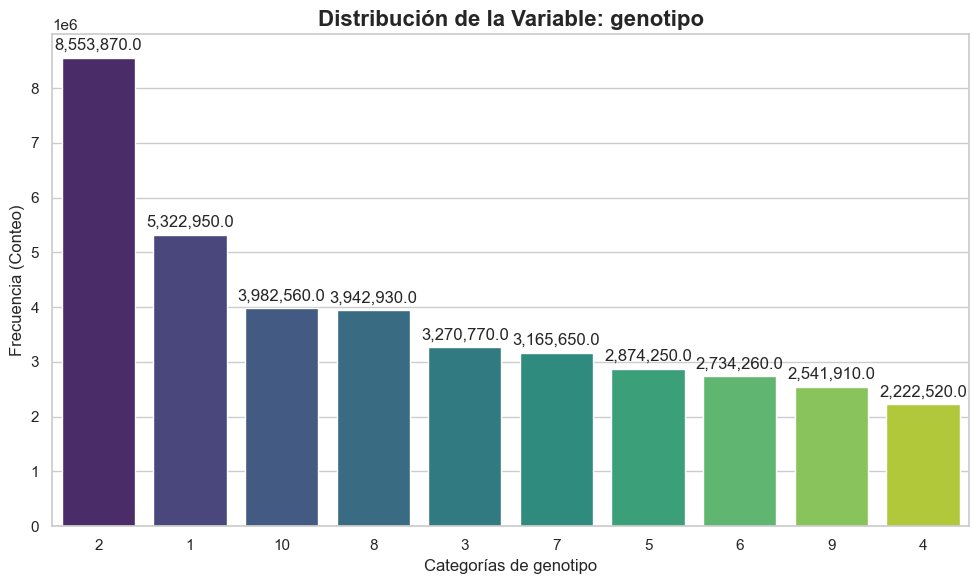

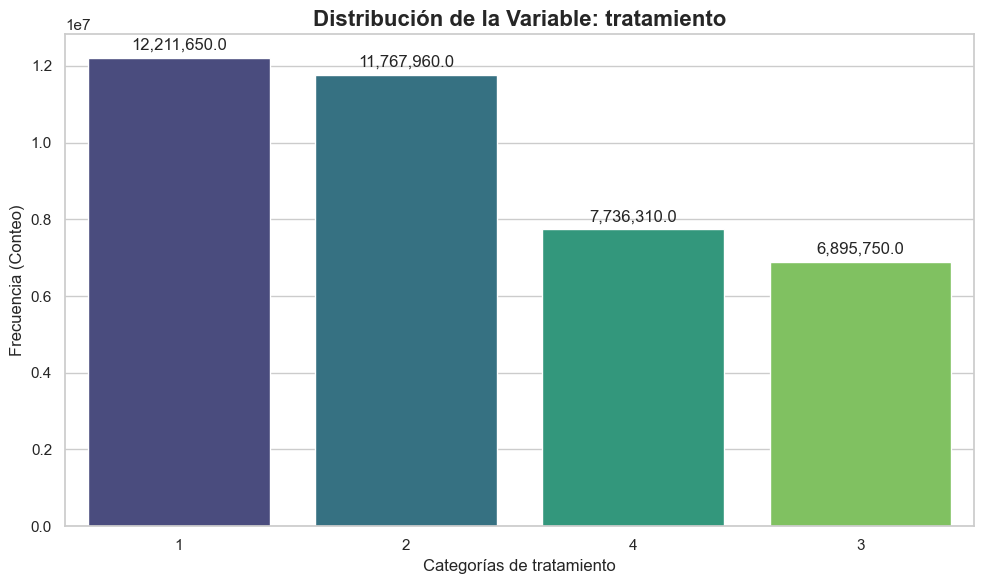

In [17]:
for col in columnas_categoricas:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x=col, data=data, order=data[col].value_counts().index, palette='viridis')
    ax.set_title(f'Distribución de la Variable: {col}', fontsize=16, fontweight='bold')
    ax.set_xlabel(f'Categorías de {col}', fontsize=12)
    ax.set_ylabel('Frecuencia (Conteo)', fontsize=12)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')
    plt.tight_layout()
    plt.show()

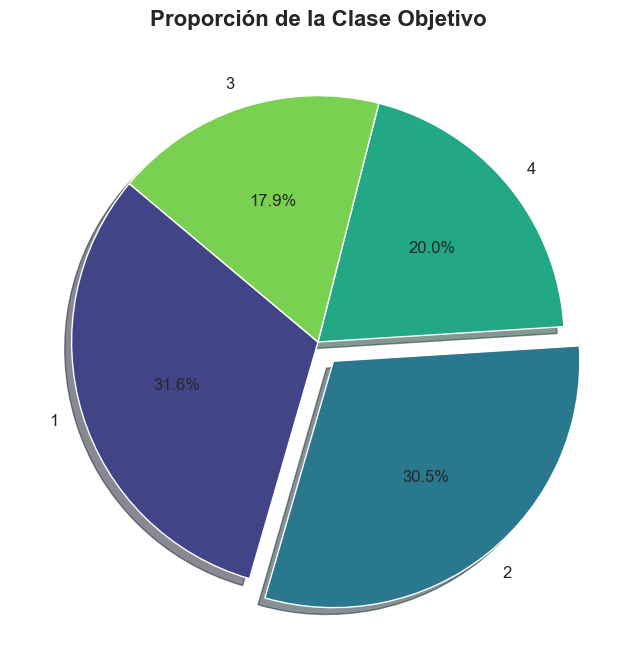

In [18]:
counts = data['tratamiento'].value_counts()
colors = sns.color_palette('viridis', len(counts))
explode = [0.1 if i == counts.idxmax() else 0 for i, _ in enumerate(counts)]

plt.figure(figsize=(8, 8))
plt.pie(counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12})
plt.title('Proporción de la Clase Objetivo', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.show()

## 3.2. Análisis de reflectancia espectral por tratamiento

In [19]:
data_long_sample = data.sample(n=min(50000, len(data)), random_state=42)

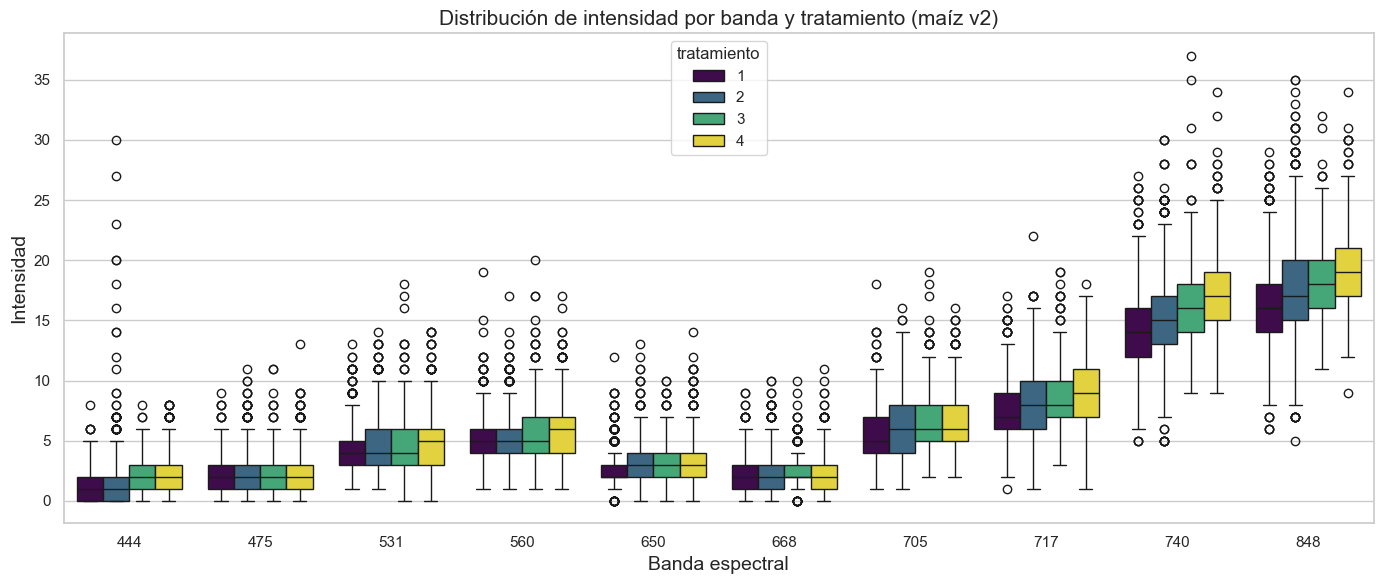

In [20]:
plt.figure(figsize=(14, 6))
ax = sns.boxplot(
    data=data_long_sample,
    x="banda",
    y="intensidad",
    hue="tratamiento",
    palette="viridis",
)
ax.set_title("Distribución de intensidad por banda y tratamiento (maíz v2)", fontsize=15)
ax.set_xlabel("Banda espectral")
ax.set_ylabel("Intensidad")
plt.tight_layout()
plt.show()

## 3.3. Matriz de correlación entre variables numéricas

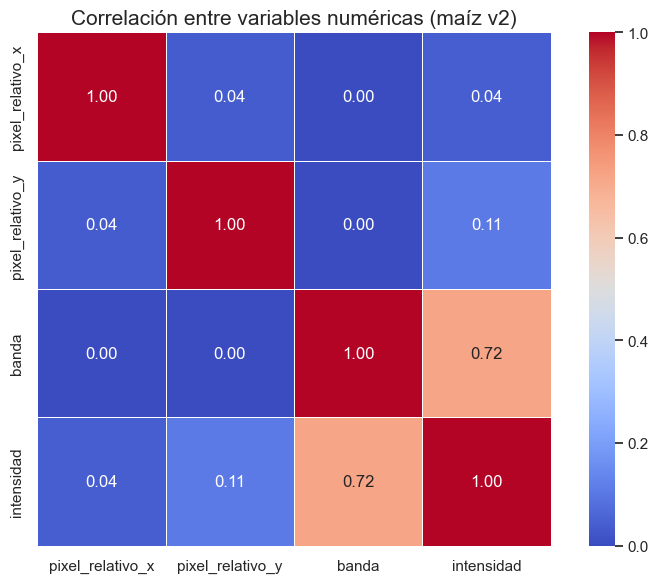

In [21]:
corr_matrix = data[columnas_numericas].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlación entre variables numéricas (maíz v2)", fontsize=15)
plt.tight_layout()
plt.show()

# 4. Preprocesamiento de Datos

## 4.1 Definición de características y grupo

In [22]:
# Columnas de features y objetivo
feature_cols = ["pixel_relativo_x", "pixel_relativo_y", "genotipo", "banda", "intensidad"]
target_col = "tratamiento"

# Columna de agrupación para evitar fuga de datos
if "object_id" in data_train.columns and "object_id" in data_test.columns:
    group_col = "object_id"
else:
    raise ValueError("No se encontró columna de grupo 'object_id' en el dataset.")

required_cols = feature_cols + [target_col, group_col]
missing_train = [c for c in required_cols if c not in data_train.columns]
missing_test  = [c for c in required_cols if c not in data_test.columns]
if missing_train or missing_test:
    raise ValueError(f"Faltan columnas. train: {missing_train}, test: {missing_test}")

# Separar en conjuntos de entrenamiento y prueba
X_train = data_train[feature_cols].copy()
y_train = data_train[target_col].copy()
groups_train = data_train[group_col].copy()

X_test = data_test[feature_cols].copy()
y_test = data_test[target_col].copy()
groups_test = data_test[group_col].copy()

print(f"Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Columna de grupo usada: {group_col}")

Train: 26,561,080 filas | Test: 12,050,590 filas
Features (5): ['pixel_relativo_x', 'pixel_relativo_y', 'genotipo', 'banda', 'intensidad']
Columna de grupo usada: object_id


In [23]:
overlap_groups = set(groups_train.astype(str)).intersection(set(groups_test.astype(str)))
print(f"Grupos únicos train: {groups_train.nunique():,}")
print(f"Grupos únicos test:  {groups_test.nunique():,}")
print(f"Cruce de grupos train/test: {len(overlap_groups)}")
if len(overlap_groups) > 0:
    print("⚠️ Advertencia: hay fuga de grupos entre train y test")
else:
    print("✅ Sin fuga de grupos entre train y test")

Grupos únicos train: 401
Grupos únicos test:  172
Cruce de grupos train/test: 0
✅ Sin fuga de grupos entre train y test


## 4.2 Balanceo de características `genotipo`

In [24]:
train_df = pd.concat([X_train, y_train], axis=1).copy()
train_df["__group_id__"] = groups_train.values

print("Distribución de 'genotipo' en el set de entrenamiento (ANTES):")
print(train_df['genotipo'].value_counts())
print("-" * 30)

min_size_train = int(train_df['genotipo'].value_counts().min())
train_df_resampled = train_df.groupby('genotipo', group_keys=False).sample(
    n=min_size_train, random_state=42
).reset_index(drop=True)

print("Distribución de 'genotipo' en el set de entrenamiento (DESPUÉS):")
print(train_df_resampled['genotipo'].value_counts())
print("-" * 30)

X_train_resampled = train_df_resampled.drop(columns=['tratamiento', '__group_id__'])
y_train_resampled = train_df_resampled['tratamiento']
groups_train_resampled = train_df_resampled['__group_id__']

Distribución de 'genotipo' en el set de entrenamiento (ANTES):
genotipo
2     6284270
1     3809140
10    2653970
3     2355960
8     2250510
9     2211010
7     2150940
5     1828720
6     1563450
4     1453110
Name: count, dtype: int64
------------------------------
Distribución de 'genotipo' en el set de entrenamiento (DESPUÉS):
genotipo
1     1453110
2     1453110
3     1453110
4     1453110
5     1453110
6     1453110
7     1453110
8     1453110
9     1453110
10    1453110
Name: count, dtype: int64
------------------------------


In [25]:
print("Distribución de 'tratamiento' en el set de entrenamiento (DESPUÉS del balanceo):")
print(y_train_resampled.value_counts())

Distribución de 'tratamiento' en el set de entrenamiento (DESPUÉS del balanceo):
tratamiento
1    4636870
2    3528373
4    3367874
3    2997983
Name: count, dtype: int64


## 4.3 Normalizar datos

In [26]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled  = scaler.transform(X_test)

## 4.4 Codificación de tratamiento (para XGBoost)

In [4]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_resampled)
y_test_encoded  = le.transform(y_test)

## 4.5 Persistencia de datos procesados

In [28]:
os.makedirs("results/data", exist_ok=True)
np.savez(
    "results/data/train_data_maiz_v2.npz",
    X_train_scaled=X_train_scaled,
    X_test_scaled=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    X_train_resampled=X_train_resampled,
    y_train_resampled=y_train_resampled,
    y_train_encoded=y_train_encoded,
    y_test_encoded=y_test_encoded,
    groups_train_resampled=groups_train_resampled,
)
print("✅ Datos procesados guardados en results/data/train_data_maiz_v2.npz")

✅ Datos procesados guardados en results/data/train_data_maiz_v2.npz


## 4.6 Cargar datos preprocesados (opcional)

In [3]:
train_data = np.load("results/data/train_data_maiz_v2.npz", allow_pickle=True)
X_train_scaled          = train_data["X_train_scaled"]
X_test_scaled           = train_data["X_test_scaled"]
y_train                 = train_data["y_train"]
y_test                  = train_data["y_test"]
X_train_resampled       = train_data["X_train_resampled"]
y_train_resampled       = train_data["y_train_resampled"]
y_train_encoded         = train_data["y_train_encoded"]
y_test_encoded          = train_data["y_test_encoded"]
groups_train_resampled  = train_data["groups_train_resampled"] if "groups_train_resampled" in train_data.files else None

# 5. Entrenamiento de Modelos de Aprendizaje Automático

Se implementan y entrenan cuatro algoritmos de clasificación:
1. **K-Nearest Neighbors (KNN)**: Clasificador basado en instancias
2. **Random Forest (RF)**: Ensemble de árboles de decisión
3. **XGBoost**: Gradient boosting optimizado
4. **MLP**: Red neuronal artificial

In [29]:
def medir_tiempo_entrenamiento(func):
    def wrapper(*args, nombre_modelo=None, **kwargs):
        modelo = args[0] if args else kwargs.get("estimator")
        etiqueta = nombre_modelo or (modelo.__class__.__name__ if modelo is not None else func.__name__)
        inicio = time.time()
        resultado = func(*args, **kwargs)
        fin = time.time()
        print(f"⏱️ {etiqueta} entrenado en {fin - inicio:.2f}s")
        return resultado
    return wrapper

@medir_tiempo_entrenamiento
def train_model(estimator):
    estimator.fit(X_train_scaled, y_train_resampled)
    return estimator

os.makedirs("models/maiz", exist_ok=True)

## 5.1 K-Nearest Neighbors (KNN)

In [30]:
knn = KNeighborsClassifier(n_jobs=-1)

In [31]:
knn_classifier = train_model(knn)

⏱️ KNeighborsClassifier entrenado en 48.44s


In [32]:
joblib.dump(knn_classifier, 'models/maiz/modelo_knn_v2.pkl')

['models/maiz/modelo_knn_v2.pkl']

## 5.2 Random Forest (RF)

In [33]:
rfc = RandomForestClassifier(n_jobs=1, n_estimators=70, random_state=12)

In [34]:
rf_classifier = train_model(rfc)

⏱️ RandomForestClassifier entrenado en 4678.08s


In [ ]:
joblib.dump(rf_classifier, 'models/maiz/modelo_rfc_v2.pkl')

## 5.3 XGBoost

In [45]:
xgbc = xgb.XGBClassifier(objective='multi:softmax', random_state=42)

In [46]:
inicio = time.time()
xgb_classifier = xgbc.fit(X_train_scaled, y_train_encoded)
fin = time.time()
print(f"⏱️ XGBClassifier entrenado en {fin - inicio:.2f}s")

⏱️ XGBClassifier entrenado en 272.03s


In [47]:
joblib.dump(xgb_classifier, 'models/maiz/modelo_xgb_v2.pkl')

['models/maiz/modelo_xgb_v2.pkl']

## 5.4 MLP

In [51]:
mlp = MLPClassifier()

In [52]:
mlp_classifier = train_model(mlp)

⏱️ MLPClassifier entrenado en 3862.17s


In [53]:
joblib.dump(mlp_classifier, 'models/maiz/modelo_mlp_v2.pkl')

['models/maiz/modelo_mlp_v2.pkl']

## 5.5 Carga de modelos previamente entrenados

In [ ]:
knn_classifier = joblib.load('models/maiz/modelo_knn_v2.pkl')

In [ ]:
rf_classifier = joblib.load('models/maiz/modelo_rfc_v2.pkl')

In [5]:
xgb_classifier = joblib.load('models/maiz/modelo_xgb_v2.pkl')

In [6]:
mlp_classifier = joblib.load('models/maiz/modelo_mlp_v2.pkl')

# 6. Generación de Predicciones

In [8]:
def medir_tiempo_prediccion(func):
    def wrapper(estimator, type: str):
        etiqueta = estimator.__class__.__name__
        inicio = time.time()
        resultado = func(estimator, type)
        fin = time.time()
        print(f"⏱️ {etiqueta} ({type}) predicho en {fin - inicio:.2f}s")
        return resultado
    return wrapper

@medir_tiempo_prediccion
def make_prediction(estimator, type: str):
    if type == "test":
        return estimator.predict(X_test_scaled)
    elif type == "train":
        return estimator.predict(X_train_scaled)

os.makedirs("results/predictions/maiz/test",  exist_ok=True)
os.makedirs("results/predictions/maiz/train", exist_ok=True)

## 6.1 Predicciones con KNN

In [40]:
knn_prediction_test  = make_prediction(knn_classifier, "test")

⏱️ KNeighborsClassifier (test) predicho en 527.88s


In [41]:
knn_prediction_train = make_prediction(knn_classifier, "train")

⏱️ KNeighborsClassifier (train) predicho en 743.03s


In [42]:
joblib.dump(knn_prediction_test,  "results/predictions/maiz/test/predicciones_knn_test_v2.pkl")
joblib.dump(knn_prediction_train, "results/predictions/maiz/train/predicciones_knn_train_v2.pkl")

['results/predictions/maiz/train/predicciones_knn_train_v2.pkl']

In [21]:
knn_prediction_test = joblib.load('results/predictions/maiz/test/predicciones_knn_test_v2.pkl')
knn_prediction_train = joblib.load('results/predictions/maiz/train/predicciones_knn_train_v2.pkl')

In [43]:
print("=" * 50)
print("Clasificación Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, knn_prediction_train))
print("\n" + "=" * 50)
print("Clasificación Report - Prueba")
print("=" * 50)
print(classification_report(y_test, knn_prediction_test))

Clasificación Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.60      0.75      0.67   4636870
           2       0.65      0.63      0.64   3528373
           3       0.62      0.55      0.58   2997983
           4       0.71      0.54      0.61   3367874

    accuracy                           0.63  14531100
   macro avg       0.64      0.62      0.63  14531100
weighted avg       0.64      0.63      0.63  14531100


Clasificación Report - Prueba
              precision    recall  f1-score   support

           1       0.33      0.44      0.38   3450760
           2       0.37      0.30      0.33   4322840
           3       0.26      0.23      0.24   2233900
           4       0.21      0.21      0.21   2043090

    accuracy                           0.31  12050590
   macro avg       0.29      0.29      0.29  12050590
weighted avg       0.31      0.31      0.31  12050590



In [22]:
knn_cm_train = confusion_matrix(y_true=y_train_resampled, y_pred=knn_prediction_train)
knn_cm_test  = confusion_matrix(y_true=y_test,            y_pred=knn_prediction_test)

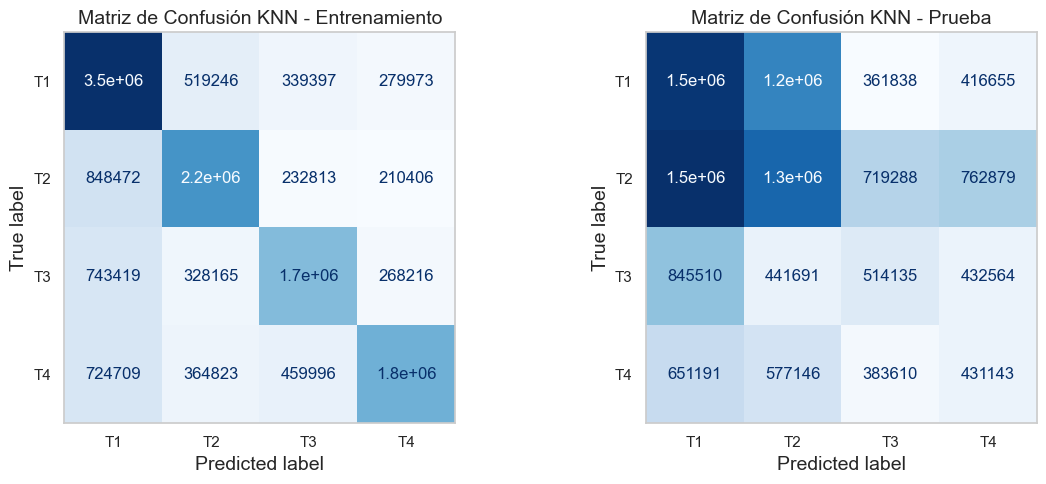

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']
for ax, matriz, split in zip(axes, [knn_cm_train, knn_cm_test], ["Entrenamiento", "Prueba"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión KNN - {split}', fontsize=14)
    ax.grid(False)
plt.tight_layout()
plt.show()

## 6.2 Predicciones con Random Forest

In [37]:
rf_prediction_test  = make_prediction(rf_classifier, "test")
rf_prediction_train = make_prediction(rf_classifier, "train")
joblib.dump(rf_prediction_test,  "results/predictions/maiz/test/predicciones_rf_test_v2.pkl")
joblib.dump(rf_prediction_train, "results/predictions/maiz/train/predicciones_rf_train_v2.pkl")

⏱️ RandomForestClassifier (test) predicho en 452.60s
⏱️ RandomForestClassifier (train) predicho en 860.12s


['results/predictions/maiz/train/predicciones_rf_train_v2.pkl']

In [23]:
rf_prediction_test = joblib.load('results/predictions/maiz/test/predicciones_rf_test_v2.pkl')
rf_prediction_train = joblib.load('results/predictions/maiz/train/predicciones_rf_train_v2.pkl')

In [38]:
print("=" * 50)
print("Clasificación Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, rf_prediction_train))
print("\n" + "=" * 50)
print("Clasificación Report - Prueba")
print("=" * 50)
print(classification_report(y_test, rf_prediction_test))

Clasificación Report - Entrenamiento
              precision    recall  f1-score   support

           1       1.00      1.00      1.00   4636870
           2       1.00      1.00      1.00   3528373
           3       1.00      1.00      1.00   2997983
           4       1.00      1.00      1.00   3367874

    accuracy                           1.00  14531100
   macro avg       1.00      1.00      1.00  14531100
weighted avg       1.00      1.00      1.00  14531100


Clasificación Report - Prueba
              precision    recall  f1-score   support

           1       0.32      0.35      0.34   3450760
           2       0.36      0.29      0.32   4322840
           3       0.28      0.26      0.27   2233900
           4       0.22      0.29      0.25   2043090

    accuracy                           0.30  12050590
   macro avg       0.30      0.30      0.29  12050590
weighted avg       0.31      0.30      0.30  12050590



In [24]:
rf_cm_train = confusion_matrix(y_true=y_train_resampled, y_pred=rf_prediction_train)
rf_cm_test  = confusion_matrix(y_true=y_test,            y_pred=rf_prediction_test)

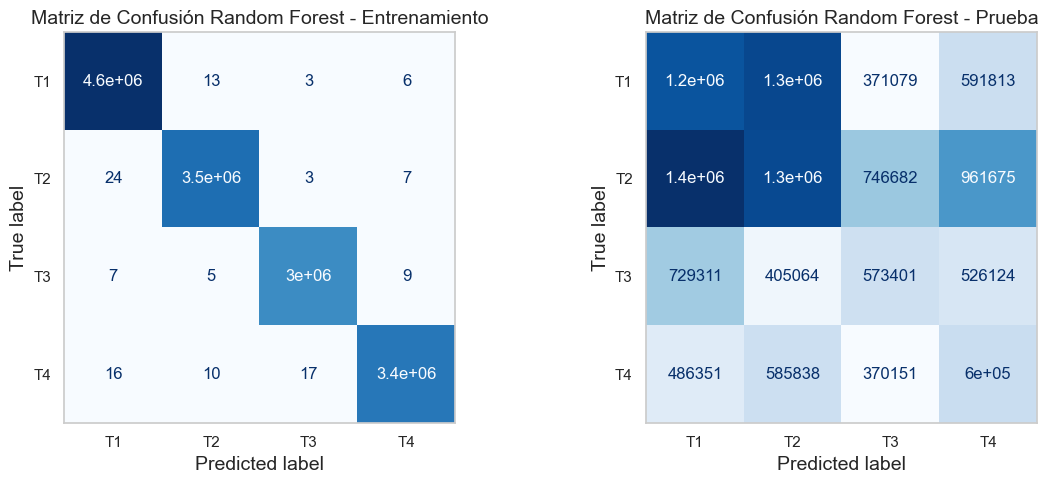

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matriz, split in zip(axes, [rf_cm_train, rf_cm_test], ["Entrenamiento", "Prueba"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['T1','T2','T3','T4'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión Random Forest - {split}', fontsize=14)
    ax.grid(False)
plt.tight_layout()
plt.show()

## 6.3 Predicciones con XGBoost

In [48]:
xgb_prediction_test  = make_prediction(xgb_classifier, "test")
xgb_prediction_train = make_prediction(xgb_classifier, "train")
joblib.dump(xgb_prediction_test,  "results/predictions/maiz/test/predicciones_xgb_test_v2.pkl")
joblib.dump(xgb_prediction_train, "results/predictions/maiz/train/predicciones_xgb_train_v2.pkl")

⏱️ XGBClassifier (test) predicho en 16.73s
⏱️ XGBClassifier (train) predicho en 19.79s


['results/predictions/maiz/train/predicciones_xgb_train_v2.pkl']

In [15]:
xgb_prediction_test = joblib.load('results/predictions/maiz/test/predicciones_xgb_test_v2.pkl')
xgb_prediction_train = joblib.load('results/predictions/maiz/train/predicciones_xgb_train_v2.pkl')

In [49]:
print("=" * 50)
print("Clasificación Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_encoded, xgb_prediction_train))
print("\n" + "=" * 50)
print("Clasificación Report - Prueba")
print("=" * 50)
print(classification_report(y_test_encoded, xgb_prediction_test))

Clasificación Report - Entrenamiento
              precision    recall  f1-score   support

           0       0.46      0.65      0.54   4636870
           1       0.56      0.47      0.51   3528373
           2       0.47      0.33      0.39   2997983
           3       0.50      0.43      0.46   3367874

    accuracy                           0.49  14531100
   macro avg       0.50      0.47      0.48  14531100
weighted avg       0.50      0.49      0.48  14531100


Clasificación Report - Prueba
              precision    recall  f1-score   support

           0       0.31      0.46      0.37   3450760
           1       0.35      0.27      0.31   4322840
           2       0.24      0.16      0.19   2233900
           3       0.23      0.24      0.23   2043090

    accuracy                           0.30  12050590
   macro avg       0.28      0.28      0.28  12050590
weighted avg       0.30      0.30      0.29  12050590



In [18]:
xgb_cm_train = confusion_matrix(y_true=y_train_encoded, y_pred=xgb_prediction_train)
xgb_cm_test  = confusion_matrix(y_true=y_test_encoded,  y_pred=xgb_prediction_test)

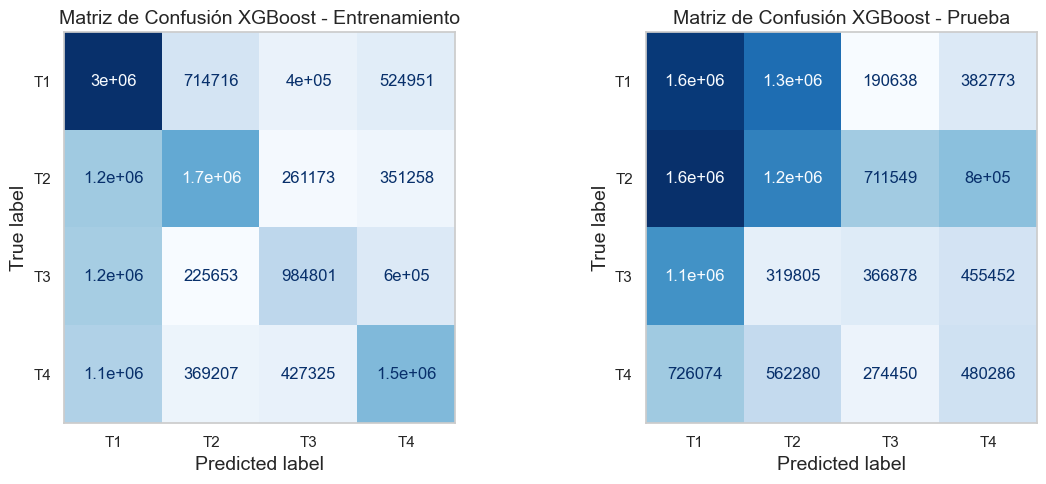

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matriz, split in zip(axes, [xgb_cm_train, xgb_cm_test], ["Entrenamiento", "Prueba"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['T1','T2','T3','T4'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión XGBoost - {split}', fontsize=14)
    ax.grid(False)
plt.tight_layout()
plt.show()

## 6.4 Predicciones con MLP

In [12]:
mlp_prediction_test  = make_prediction(mlp_classifier, "test")
joblib.dump(mlp_prediction_test,  "results/predictions/maiz/test/predicciones_mlp_test_v2.pkl")

⏱️ MLPClassifier (test) predicho en 16.84s


['results/predictions/maiz/test/predicciones_mlp_test_v2.pkl']

In [9]:
mlp_prediction_train = make_prediction(mlp_classifier, "train")
joblib.dump(mlp_prediction_train, "results/predictions/maiz/train/predicciones_mlp_train_v2.pkl")

⏱️ MLPClassifier (train) predicho en 50.08s


['results/predictions/maiz/train/predicciones_mlp_train_v2.pkl']

In [13]:
print("=" * 50)
print("Clasificación Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, mlp_prediction_train))
print("\n" + "=" * 50)
print("Clasificación Report - Prueba")
print("=" * 50)
print(classification_report(y_test, mlp_prediction_test))

Clasificación Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.39      0.65      0.49   4636870
           2       0.48      0.30      0.37   3528373
           3       0.36      0.21      0.27   2997983
           4       0.41      0.35      0.38   3367874

    accuracy                           0.41  14531100
   macro avg       0.41      0.38      0.38  14531100
weighted avg       0.41      0.41      0.39  14531100


Clasificación Report - Prueba
              precision    recall  f1-score   support

           1       0.31      0.55      0.40   3450760
           2       0.34      0.20      0.25   4322840
           3       0.22      0.12      0.16   2233900
           4       0.23      0.25      0.24   2043090

    accuracy                           0.29  12050590
   macro avg       0.28      0.28      0.26  12050590
weighted avg       0.29      0.29      0.27  12050590



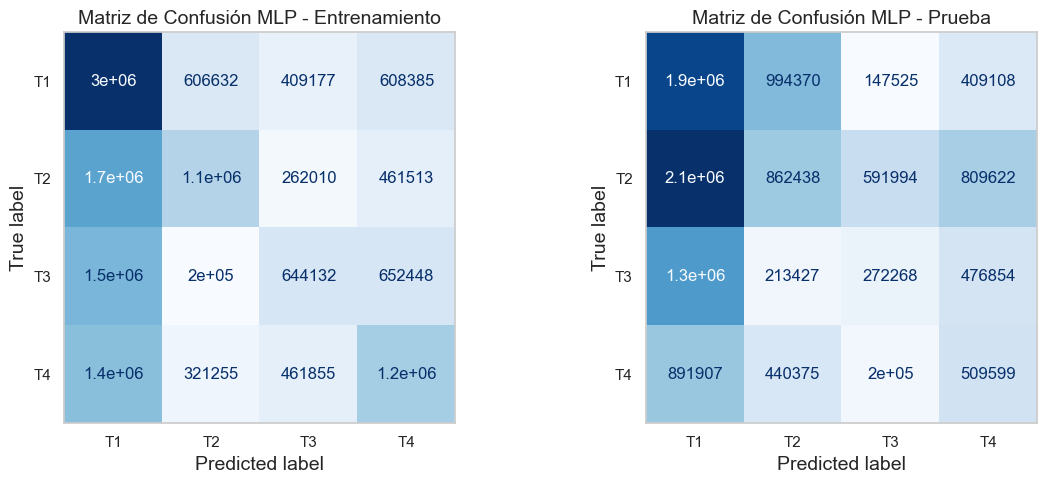

In [14]:
mlp_cm_train = confusion_matrix(y_true=y_train_resampled, y_pred=mlp_prediction_train)
mlp_cm_test  = confusion_matrix(y_true=y_test,            y_pred=mlp_prediction_test)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matriz, split in zip(axes, [mlp_cm_train, mlp_cm_test], ["Entrenamiento", "Prueba"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['T1','T2','T3','T4'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión MLP - {split}', fontsize=14)
    ax.grid(False)
plt.tight_layout()
plt.show()

# 7. Evaluación de Modelos Baseline

In [25]:
classifiers_names  = ["knn", "rfc", "xgb", "mlp"]
predictions_train  = [knn_prediction_train, rf_prediction_train, xgb_prediction_train, mlp_prediction_train]
predictions_test   = [knn_prediction_test,  rf_prediction_test,  xgb_prediction_test,  mlp_prediction_test]
cmxs_train         = [knn_cm_train, rf_cm_train, xgb_cm_train, mlp_cm_train]
cmxs_test          = [knn_cm_test,  rf_cm_test,  xgb_cm_test,  mlp_cm_test]

classifier_display_names = {
    "knn": "K-Nearest Neighbors",
    "rfc": "Random Forest",
    "xgb": "XGBoost",
    "mlp": "Perceptrón Multicapa"
}

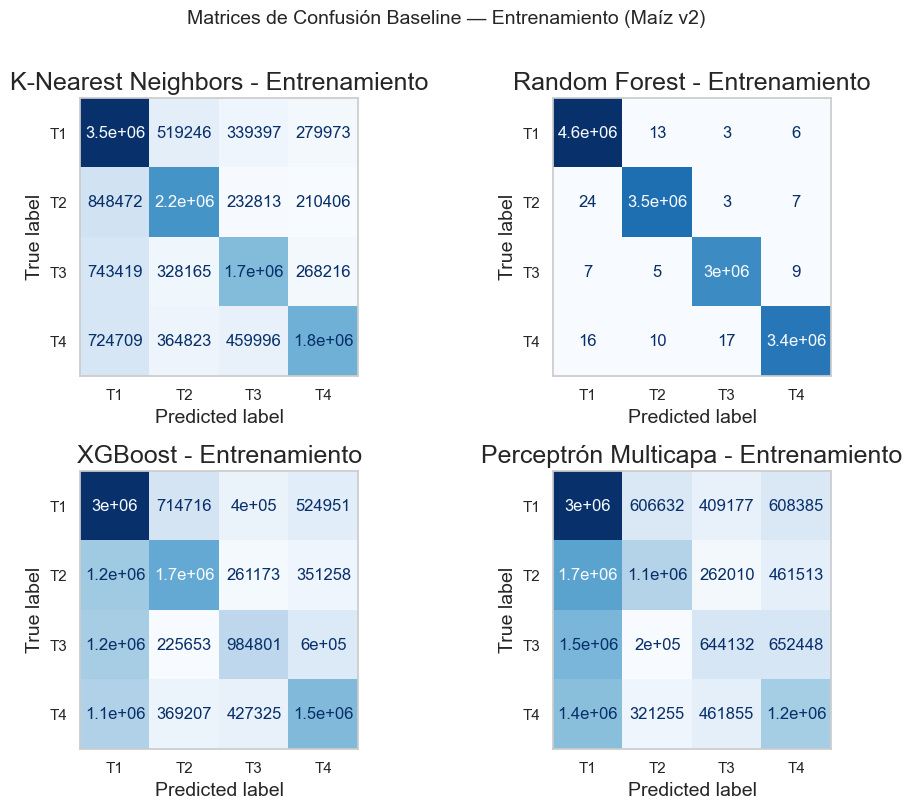

In [26]:
num_models = 4
ncols = 2
nrows = math.ceil(num_models / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i, (cm, cname) in enumerate(zip(cmxs_train, classifiers_names)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['T1','T2','T3','T4'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"{classifier_display_names[cname]} - Entrenamiento")
    axes[i].grid(False)
for j in range(num_models, len(axes)):
    axes[j].axis('off')
plt.suptitle("Matrices de Confusión Baseline — Entrenamiento (Maíz v2)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

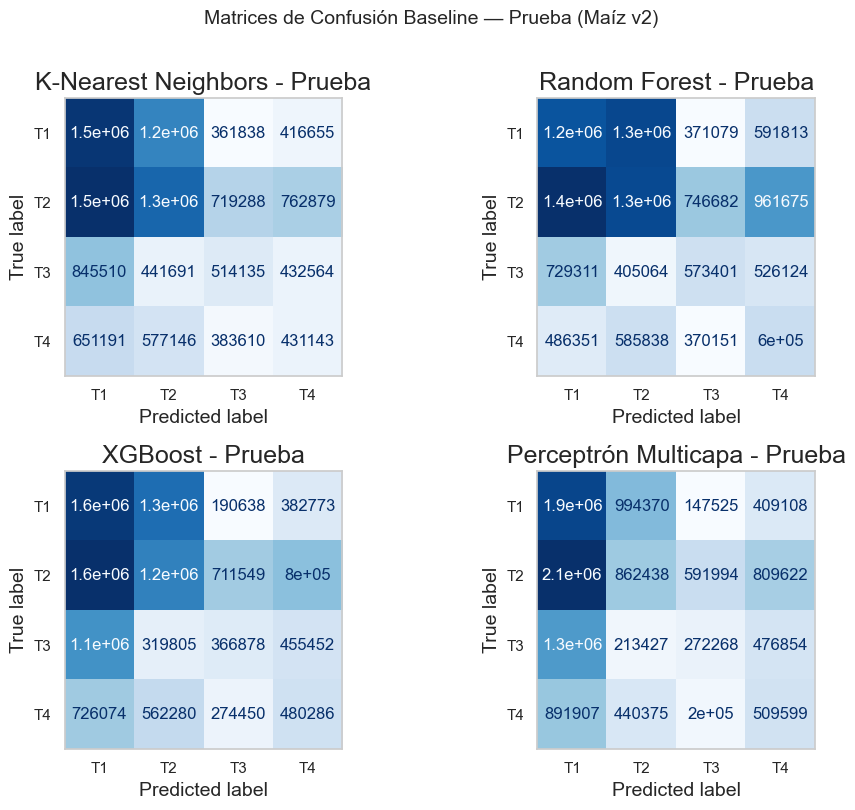

In [27]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i, (cm, cname) in enumerate(zip(cmxs_test, classifiers_names)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['T1','T2','T3','T4'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"{classifier_display_names[cname]} - Prueba")
    axes[i].grid(False)
for j in range(num_models, len(axes)):
    axes[j].axis('off')
plt.suptitle("Matrices de Confusión Baseline — Prueba (Maíz v2)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [28]:
results_list = []
for preds, cname in zip(predictions_train, classifiers_names):
    y_true_ref = y_train_encoded if cname == 'xgb' else y_train_resampled
    rd = classification_report(y_true_ref, preds, output_dict=True)
    results_list.append({'Modelo': cname, 'Accuracy': rd['accuracy'],
                         'Precision (Ponderada)': rd['weighted avg']['precision'],
                         'Recall (Ponderado)': rd['weighted avg']['recall'],
                         'F1-Score (Ponderado)': rd['weighted avg']['f1-score'],
                         'Kappa Score': cohen_kappa_score(y_true_ref, preds)})
results_df = pd.DataFrame(results_list).set_index('Modelo')
display(results_df.style.background_gradient(cmap='summer_r', axis=0))

,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.633914,0.640144,0.633914,0.631352,0.502178
rfc,0.999992,0.999992,0.999992,0.999992,0.999989
xgb,0.489306,0.495450,0.489306,0.483128,0.300695
mlp,0.406939,0.413036,0.406939,0.390454,0.180557


In [29]:
results_list = []
for preds, cname in zip(predictions_test, classifiers_names):
    y_true_ref = y_test_encoded if cname == 'xgb' else y_test
    rd = classification_report(y_true_ref, preds, output_dict=True)
    results_list.append({'Modelo': cname, 'Accuracy': rd['accuracy'],
                         'Precision (Ponderada)': rd['weighted avg']['precision'],
                         'Recall (Ponderado)': rd['weighted avg']['recall'],
                         'F1-Score (Ponderado)': rd['weighted avg']['f1-score'],
                         'Kappa Score': cohen_kappa_score(y_true_ref, preds)})
results_df = pd.DataFrame(results_list).set_index('Modelo')
display(results_df.style.background_gradient(cmap='summer_r', axis=0))

,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.311511,0.312859,0.311511,0.308501,0.055779
rfc,0.303104,0.310050,0.303104,0.304246,0.052858
xgb,0.299527,0.298638,0.299527,0.292196,0.036409
mlp,0.294099,0.292881,0.294099,0.274168,0.033154


# 8. Selección de Hiperparámetros

In [ ]:
def make_rand_grid_search(estimator, param_dist, cv_splitter):
    return RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=10,
        cv=cv_splitter,
        scoring="accuracy",
        random_state=12,
        refit=True,
    )

for stage_dir in ['hyperparameter_tuning', 'best']:
    os.makedirs(f'models/maiz/{stage_dir}', exist_ok=True)

def save_model_and_params(model, model_name, best_params, score, stage="hyperparameter_tuning"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_info = {'model': model, 'best_params': best_params, 'best_score': score,
                  'timestamp': timestamp, 'model_name': model_name, 'stage': stage}
    save_path = f'models/maiz/{stage}/{model_name}_{timestamp}_v2.pkl'
    with open(save_path, 'wb') as f:
        pickle.dump(model_info, f)
    print(f"✅ Modelo {model_name} guardado en: {save_path}")
    return save_path

def load_model_info(filepath):
    with open(filepath, 'rb') as f:
        model_info = pickle.load(f)
    print(f"📁 Modelo {model_info['model_name']} cargado | Score: {model_info['best_score']:.4f}")
    return model_info

## 8.1 Selección de muestra y validación cruzada GroupKFold

In [ ]:
HYPERPARAMETER_SAMPLE_SIZE = 0.15
RANDOM_STATE = 42

print(f"Dataset original de entrenamiento: {X_train_scaled.shape[0]:,} muestras")

X_train_sample, _, y_train_sample, _, groups_sample, _ = train_test_split(
    X_train_scaled,
    y_train_resampled,
    groups_train_resampled,
    test_size=1 - HYPERPARAMETER_SAMPLE_SIZE,
    stratify=y_train_resampled,
    random_state=RANDOM_STATE,
)

y_train_sample_encoded = le.transform(y_train_sample)
gkf = GroupKFold(n_splits=5)

print(f"Muestra para hiperparámetros: {X_train_sample.shape[0]:,} ({HYPERPARAMETER_SAMPLE_SIZE*100:.1f}%)")
print("\nDistribución de clases en muestra:")
print(pd.Series(y_train_sample).value_counts().sort_index())

In [ ]:
cv_rows = []
for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_train_sample, y_train_sample, groups_sample), start=1):
    X_tr, X_te = X_train_sample[tr_idx], X_train_sample[te_idx]
    y_tr = pd.Series(y_train_sample).iloc[tr_idx]
    y_te = pd.Series(y_train_sample).iloc[te_idx]
    fold_model = RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1)
    fold_model.fit(X_tr, y_tr)
    y_pred = fold_model.predict(X_te)
    cv_rows.append({"fold": fold, "accuracy": accuracy_score(y_te, y_pred), "f1_macro": f1_score(y_te, y_pred, average="macro")})

cv_df = pd.DataFrame(cv_rows)
display(cv_df)
summary_cv = pd.DataFrame({"metric": ["accuracy", "f1_macro"],
                            "mean": [cv_df["accuracy"].mean(), cv_df["f1_macro"].mean()],
                            "std":  [cv_df["accuracy"].std(ddof=1), cv_df["f1_macro"].std(ddof=1)]})
display(summary_cv)

## 8.2 KNN — Búsqueda de hiperparámetros

In [ ]:
knn_param_grid = {
    'n_neighbors': [15, 30, 50],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],
}

In [ ]:
print("🔍 Iniciando búsqueda de hiperparámetros para KNN...")
search_start = time.time()
knn_gridSearchCV = make_rand_grid_search(KNeighborsClassifier(n_jobs=-1), knn_param_grid, gkf)
knn_gridSearchCV.fit(X_train_sample, y_train_sample, groups=groups_sample)
search_elapsed = time.time() - search_start
print(f"⏱️ Búsqueda KNN: {search_elapsed:.2f}s ({search_elapsed/60:.2f} min)")
save_model_and_params(knn_gridSearchCV, "KNN", knn_gridSearchCV.best_params_, knn_gridSearchCV.best_score_, "hyperparameter_tuning")
print(f"Mejores parámetros: {knn_gridSearchCV.best_params_}")
print(f"Score CV: {knn_gridSearchCV.best_score_:.4f}")

In [ ]:
print(f"🚀 Entrenando KNN final con {X_train_scaled.shape[0]:,} muestras...")
knn_final = KNeighborsClassifier(n_jobs=-1, **knn_gridSearchCV.best_params_)
train_start = time.time()
knn_final.fit(X_train_scaled, y_train_resampled)
print(f"⏱️ KNN final entrenado en {time.time()-train_start:.2f}s")
save_model_and_params(knn_final, "KNN_final", knn_gridSearchCV.best_params_, knn_gridSearchCV.best_score_, "best")

In [ ]:
knn_y_test_pred  = knn_final.predict(X_test_scaled)
knn_y_train_pred = knn_final.predict(X_train_scaled)
joblib.dump(knn_y_test_pred,  "results/predictions/maiz/test/best_predicciones_knn_test_v2.pkl")
joblib.dump(knn_y_train_pred, "results/predictions/maiz/train/best_predicciones_knn_train_v2.pkl")

In [ ]:
print(classification_report(y_train_resampled, knn_y_train_pred))
print(classification_report(y_test, knn_y_test_pred))

In [ ]:
knn_cm_train = confusion_matrix(y_true=y_train_resampled, y_pred=knn_y_train_pred)
knn_cm_test  = confusion_matrix(y_true=y_test,            y_pred=knn_y_test_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matriz, split in zip(axes, [knn_cm_train, knn_cm_test], ["Entrenamiento", "Prueba"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['T1','T2','T3','T4'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'KNN Optimizado - {split}', fontsize=14)
    ax.grid(False)
plt.tight_layout()
plt.show()

## 8.3 Random Forest — Búsqueda de hiperparámetros

In [ ]:
rf_param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
    'max_features': ['sqrt', 'log2'],
}

In [ ]:
print("🔍 Iniciando búsqueda de hiperparámetros para Random Forest...")
search_start = time.time()
rf_gridSearchCV = make_rand_grid_search(RandomForestClassifier(n_jobs=-1, random_state=12), rf_param_grid, gkf)
rf_gridSearchCV.fit(X_train_sample, y_train_sample, groups=groups_sample)
search_elapsed = time.time() - search_start
print(f"⏱️ Búsqueda RF: {search_elapsed:.2f}s ({search_elapsed/60:.2f} min)")
save_model_and_params(rf_gridSearchCV, "RandomForest", rf_gridSearchCV.best_params_, rf_gridSearchCV.best_score_, "hyperparameter_tuning")
print(f"Mejores parámetros: {rf_gridSearchCV.best_params_}")
print(f"Score CV: {rf_gridSearchCV.best_score_:.4f}")

In [ ]:
print(f"🚀 Entrenando Random Forest final con {X_train_scaled.shape[0]:,} muestras...")
rf_final = RandomForestClassifier(n_jobs=-1, random_state=12, **rf_gridSearchCV.best_params_)
train_start = time.time()
rf_final.fit(X_train_scaled, y_train_resampled)
print(f"⏱️ RF final entrenado en {time.time()-train_start:.2f}s")
save_model_and_params(rf_final, "RandomForest_final", rf_gridSearchCV.best_params_, rf_gridSearchCV.best_score_, "best")

In [ ]:
rf_y_test_pred  = rf_final.predict(X_test_scaled)
rf_y_train_pred = rf_final.predict(X_train_scaled)
joblib.dump(rf_y_test_pred,  "results/predictions/maiz/test/best_predicciones_rf_test_v2.pkl")
joblib.dump(rf_y_train_pred, "results/predictions/maiz/train/best_predicciones_rf_train_v2.pkl")

In [ ]:
print(classification_report(y_train_resampled, rf_y_train_pred))
print(classification_report(y_test, rf_y_test_pred))

In [ ]:
rf_cm_train = confusion_matrix(y_true=y_train_resampled, y_pred=rf_y_train_pred)
rf_cm_test  = confusion_matrix(y_true=y_test,            y_pred=rf_y_test_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matriz, split in zip(axes, [rf_cm_train, rf_cm_test], ["Entrenamiento", "Prueba"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['T1','T2','T3','T4'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Random Forest Optimizado - {split}', fontsize=14)
    ax.grid(False)
plt.tight_layout()
plt.show()

## 8.4 XGBoost — Búsqueda de hiperparámetros

In [ ]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8],
    'reg_lambda': [1, 10, 50],
    'gamma': [0, 1, 5],
}

In [ ]:
print("🔍 Iniciando búsqueda de hiperparámetros para XGBoost...")
search_start = time.time()
xgb_gridSearchCV = make_rand_grid_search(xgb.XGBClassifier(random_state=42), xgb_param_grid, gkf)
xgb_gridSearchCV.fit(X_train_sample, y_train_sample_encoded, groups=groups_sample)
search_elapsed = time.time() - search_start
print(f"⏱️ Búsqueda XGB: {search_elapsed:.2f}s ({search_elapsed/60:.2f} min)")
save_model_and_params(xgb_gridSearchCV, "XGBoost", xgb_gridSearchCV.best_params_, xgb_gridSearchCV.best_score_, "hyperparameter_tuning")
print(f"Mejores parámetros: {xgb_gridSearchCV.best_params_}")
print(f"Score CV: {xgb_gridSearchCV.best_score_:.4f}")

In [ ]:
print(f"🚀 Entrenando XGBoost final con {X_train_scaled.shape[0]:,} muestras...")
xgb_final = xgb.XGBClassifier(random_state=42, **xgb_gridSearchCV.best_params_)
train_start = time.time()
xgb_final.fit(X_train_scaled, y_train_encoded)
print(f"⏱️ XGBoost final entrenado en {time.time()-train_start:.2f}s")
save_model_and_params(xgb_final, "XGBoost_final", xgb_gridSearchCV.best_params_, xgb_gridSearchCV.best_score_, "best")

In [ ]:
xgb_y_test_pred  = xgb_final.predict(X_test_scaled)
xgb_y_train_pred = xgb_final.predict(X_train_scaled)
joblib.dump(xgb_y_test_pred,  "results/predictions/maiz/test/best_predicciones_xgb_test_v2.pkl")
joblib.dump(xgb_y_train_pred, "results/predictions/maiz/train/best_predicciones_xgb_train_v2.pkl")

In [ ]:
print(classification_report(y_train_encoded, xgb_y_train_pred))
print(classification_report(y_test_encoded, xgb_y_test_pred))

In [ ]:
xgb_cm_train = confusion_matrix(y_true=y_train_encoded, y_pred=xgb_y_train_pred)
xgb_cm_test  = confusion_matrix(y_true=y_test_encoded,  y_pred=xgb_y_test_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matriz, split in zip(axes, [xgb_cm_train, xgb_cm_test], ["Entrenamiento", "Prueba"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['T1','T2','T3','T4'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'XGBoost Optimizado - {split}', fontsize=14)
    ax.grid(False)
plt.tight_layout()
plt.show()

## 8.5 MLP — Búsqueda de hiperparámetros

In [ ]:
mlp_param_grid = [
    {
        'hidden_layer_sizes': [(100, 100, 100), (128, 64, 32)],
        'batch_size': [256],
        'learning_rate_init': [0.001],
        'alpha': [1e-4],
        'early_stopping': [True],
    }
]

In [ ]:
print("🔍 Iniciando búsqueda de hiperparámetros para MLP...")
search_start = time.time()
mlp_gridSearchCV = make_rand_grid_search(MLPClassifier(), mlp_param_grid, gkf)
mlp_gridSearchCV.fit(X_train_sample, y_train_sample, groups=groups_sample)
search_elapsed = time.time() - search_start
print(f"⏱️ Búsqueda MLP: {search_elapsed:.2f}s ({search_elapsed/60:.2f} min)")
save_model_and_params(mlp_gridSearchCV, "MLP", mlp_gridSearchCV.best_params_, mlp_gridSearchCV.best_score_, "hyperparameter_tuning")
print(f"Mejores parámetros: {mlp_gridSearchCV.best_params_}")
print(f"Score CV: {mlp_gridSearchCV.best_score_:.4f}")

In [ ]:
print(f"🚀 Entrenando MLP final con {X_train_scaled.shape[0]:,} muestras...")
mlp_final = MLPClassifier(**mlp_gridSearchCV.best_params_)
train_start = time.time()
mlp_final.fit(X_train_scaled, y_train_resampled)
print(f"⏱️ MLP final entrenado en {time.time()-train_start:.2f}s")
save_model_and_params(mlp_final, "MLP_final", mlp_gridSearchCV.best_params_, mlp_gridSearchCV.best_score_, "best")

In [ ]:
mlp_y_test_pred  = mlp_final.predict(X_test_scaled)
mlp_y_train_pred = mlp_final.predict(X_train_scaled)
joblib.dump(mlp_y_test_pred,  "results/predictions/maiz/test/best_predicciones_mlp_test_v2.pkl")
joblib.dump(mlp_y_train_pred, "results/predictions/maiz/train/best_predicciones_mlp_train_v2.pkl")

In [ ]:
print(classification_report(y_train_resampled, mlp_y_train_pred))
print(classification_report(y_test, mlp_y_test_pred))

In [ ]:
mlp_cm_train = confusion_matrix(y_true=y_train_resampled, y_pred=mlp_y_train_pred)
mlp_cm_test  = confusion_matrix(y_true=y_test,            y_pred=mlp_y_test_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, matriz, split in zip(axes, [mlp_cm_train, mlp_cm_test], ["Entrenamiento", "Prueba"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['T1','T2','T3','T4'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'MLP Optimizado - {split}', fontsize=14)
    ax.grid(False)
plt.tight_layout()
plt.show()

## 8.6 Evaluación de modelos optimizados

In [ ]:
classifiers_names  = ["knn", "rfc", "xgb", "mlp"]
predictions_train  = [knn_y_train_pred, rf_y_train_pred, xgb_y_train_pred, mlp_y_train_pred]
predictions_test   = [knn_y_test_pred,  rf_y_test_pred,  xgb_y_test_pred,  mlp_y_test_pred]

In [ ]:
results_list = []
for preds, cname in zip(predictions_train, classifiers_names):
    y_true_ref = y_train_encoded if cname == 'xgb' else y_train_resampled
    rd = classification_report(y_true_ref, preds, output_dict=True)
    results_list.append({'Modelo': cname, 'Accuracy': rd['accuracy'],
                         'Precision (Ponderada)': rd['weighted avg']['precision'],
                         'Recall (Ponderado)': rd['weighted avg']['recall'],
                         'F1-Score (Ponderado)': rd['weighted avg']['f1-score'],
                         'Kappa Score': cohen_kappa_score(y_true_ref, preds)})
results_df = pd.DataFrame(results_list).set_index('Modelo')
print("Comparativo de métricas — Entrenamiento (modelos optimizados):")
display(results_df.style.background_gradient(cmap='summer_r', axis=0))

In [ ]:
results_list = []
for preds, cname in zip(predictions_test, classifiers_names):
    y_true_ref = y_test_encoded if cname == 'xgb' else y_test
    rd = classification_report(y_true_ref, preds, output_dict=True)
    results_list.append({'Modelo': cname, 'Accuracy': rd['accuracy'],
                         'Precision (Ponderada)': rd['weighted avg']['precision'],
                         'Recall (Ponderado)': rd['weighted avg']['recall'],
                         'F1-Score (Ponderado)': rd['weighted avg']['f1-score'],
                         'Kappa Score': cohen_kappa_score(y_true_ref, preds)})
results_df = pd.DataFrame(results_list).set_index('Modelo')
print("Comparativo de métricas — Prueba (modelos optimizados):")
display(results_df.style.background_gradient(cmap='summer_r', axis=0))

# 9. Análisis de Costos Computacionales

Se consolidan los tiempos de entrenamiento y búsqueda de hiperparámetros y se visualiza la relación costo–beneficio para seleccionar el modelo más adecuado para producción.

In [ ]:
# Actualizar con los tiempos reales registrados durante el entrenamiento
performance_data = {
    'Modelo': ['KNN', 'Random Forest', 'XGBoost', 'MLP'],
    'Accuracy_Test': [0.0, 0.0, 0.0, 0.0],   # Rellenar con valores reales
    'Kappa_Score':   [0.0, 0.0, 0.0, 0.0],   # Rellenar con valores reales
    'Tiempo_Entrenamiento_Min': [0.0, 0.0, 0.0, 0.0],
    'Tiempo_Texto': ['—', '—', '—', '—'],
}
df_perf = pd.DataFrame(performance_data)
display(df_perf.style
    .background_gradient(subset=['Accuracy_Test', 'Kappa_Score'], cmap='Greens')
    .background_gradient(subset=['Tiempo_Entrenamiento_Min'], cmap='Reds'))

In [ ]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.scatterplot(data=df_perf, x='Tiempo_Entrenamiento_Min', y='Accuracy_Test',
                s=150, hue='Modelo', palette='viridis')
plt.xscale('log')
plt.title('Exactitud vs Tiempo de Entrenamiento (Maíz v2)', fontsize=15, pad=20)
plt.xlabel('Tiempo de Entrenamiento (Minutos) — Escala Log', fontsize=13)
plt.ylabel('Exactitud en Prueba (Accuracy)', fontsize=13)
plt.grid(alpha=0.3)
for i in range(df_perf.shape[0]):
    plt.annotate(
        f"{df_perf.Modelo[i]}\nAcc: {df_perf.Accuracy_Test[i]:.3f}\n{df_perf.Tiempo_Texto[i]}",
        (df_perf.Tiempo_Entrenamiento_Min[i], df_perf.Accuracy_Test[i]),
        xytext=(10, 0), textcoords='offset points', va='center', fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8),
    )
plt.axhline(y=0.8, color='green', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()